# 06 - Neural Network 

A simple feedforward network (MLP), included to test whether a deep learning approach adds value over the tree based/linear models above.

**note:** with 46,000 rows and 28 tabular features, a neural network is not expected to beat XGBoost - gradient boosting is generally the stronger choice on structured data at this scale. We're testing this deliberately, not assuming it'll win, and reporting the result either way is a legitimate finding, not a failure if it doesn't outperform.


## Setup

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

train_df = pd.read_csv(Path('../../../data/processed/model_ready_train.csv'))
val_df = pd.read_csv(Path('../../../data/processed/model_ready_val.csv'))

bool_cols = train_df.select_dtypes(include='bool').columns
train_df[bool_cols] = train_df[bool_cols].astype(int)
val_df[bool_cols] = val_df[bool_cols].astype(int)

X_train = train_df.drop(columns=['Late_delivery_risk']).values.astype(np.float32)
y_train = train_df['Late_delivery_risk'].values.astype(np.float32)
X_val = val_df.drop(columns=['Late_delivery_risk']).values.astype(np.float32)
y_val = val_df['Late_delivery_risk'].values.astype(np.float32)

feature_names = train_df.drop(columns=['Late_delivery_risk']).columns.tolist()
n_features = X_train.shape[1]
print(f"Input features: {n_features}")


Using device: cpu
Input features: 28


## 1. Define the model, data loaders, and training loop

In [2]:
class DelayRiskMLP(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x)

train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
val_ds = TensorDataset(torch.tensor(X_val), torch.tensor(y_val))
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=512, shuffle=False)

model = DelayRiskMLP(n_features).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)


In [3]:
N_EPOCHS = 30
train_losses, val_losses = [], []

for epoch in range(N_EPOCHS):
    model.train()
    epoch_train_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb).squeeze()
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item() * xb.size(0)
    epoch_train_loss /= len(train_ds)

    model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb).squeeze()
            loss = criterion(preds, yb)
            epoch_val_loss += loss.item() * xb.size(0)
    epoch_val_loss /= len(val_ds)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{N_EPOCHS} — train loss: {epoch_train_loss:.4f}, val loss: {epoch_val_loss:.4f}")


Epoch 1/30 — train loss: 0.7698, val loss: 0.6908
Epoch 5/30 — train loss: 0.5935, val loss: 0.5743
Epoch 10/30 — train loss: 0.5593, val loss: 0.5532
Epoch 15/30 — train loss: 0.5423, val loss: 0.5388
Epoch 20/30 — train loss: 0.5371, val loss: 0.5389
Epoch 25/30 — train loss: 0.5349, val loss: 0.5349
Epoch 30/30 — train loss: 0.5333, val loss: 0.5318


## 2. Training curve - check for overfitting

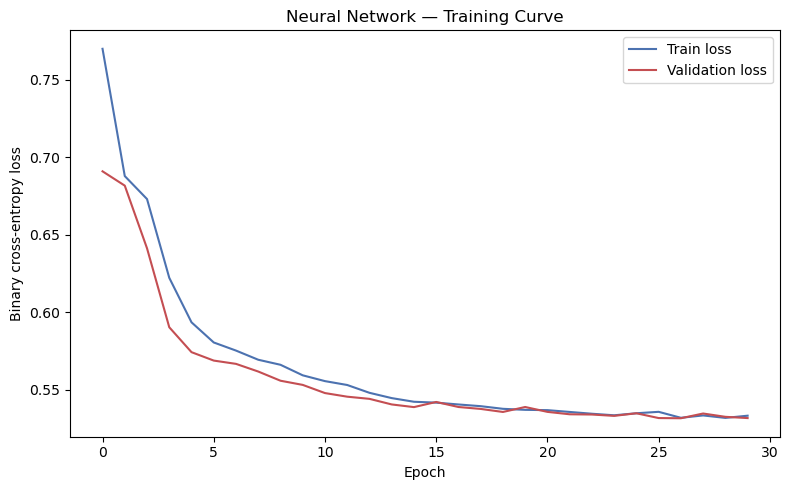

In [4]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train loss', color='#4C72B0')
plt.plot(val_losses, label='Validation loss', color='#C44E52')
plt.xlabel('Epoch')
plt.ylabel('Binary cross-entropy loss')
plt.title('Neural Network — Training Curve')
plt.legend()
plt.tight_layout()
plt.savefig('../../../reports/figures/nn_training_curve.png', dpi=120, bbox_inches='tight')
plt.show()


**What we found:**

**A clean, healthy training curve, no overfitting.** Train and validation loss decrease together smoothly throughout all 30 epochs, converging closely (train 0.5333, validation 0.5318 at the final epoch, validation loss is actually marginally *below* train loss at the end, a good sign, not a concern). There's no divergence where validation loss starts climbing while train loss keeps falling, which is what overfitting would look like. The dropout layers (0.3 and 0.2) appear to be doing their job. 30 epochs and the current architecture look like a reasonable, well-regularized fit, no need to extend training or add more regularization based on this curve.


## 3. Evaluate on the validation set

In [5]:
from sklearn.metrics import (recall_score, precision_score, f1_score,
                              roc_auc_score, average_precision_score,
                              confusion_matrix, classification_report,
                              roc_curve, precision_recall_curve)
import json
import matplotlib.pyplot as plt
import seaborn as sns  

def evaluate_and_plot(y_true, y_pred, y_score, model_name, save_prefix=None):
    metrics = {
        'model': model_name,
        'recall': recall_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_score),
        'pr_auc': average_precision_score(y_true, y_score),
    }
    print(f"--- {model_name} (validation set) ---")
    for k, v in metrics.items():
        if k != 'model':
            print(f"  {k}: {v:.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=['On time (0)', 'Late (1)']))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['On time', 'Late'], yticklabels=['On time', 'Late'])
    axes[0].set_title(f'{model_name} — Confusion Matrix')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')

    fpr, tpr, _ = roc_curve(y_true, y_score)
    axes[1].plot(fpr, tpr, label=f"AUC = {metrics['roc_auc']:.3f}", color='#4C72B0', linewidth=2)
    axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
    axes[1].set_title(f'{model_name} — ROC Curve')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend(loc='lower right')

    prec, rec, _ = precision_recall_curve(y_true, y_score)
    axes[2].plot(rec, prec, label=f"PR-AUC = {metrics['pr_auc']:.3f}", color='#C44E52', linewidth=2)
    axes[2].set_title(f'{model_name} — Precision-Recall Curve')
    axes[2].set_xlabel('Recall')
    axes[2].set_ylabel('Precision')
    axes[2].legend(loc='lower left')

    plt.tight_layout()
    if save_prefix:
        plt.savefig(f'../../../reports/figures/{save_prefix}_evaluation.png', dpi=120, bbox_inches='tight')
    plt.show()

    return metrics

def save_metrics(metrics, path):
    with open(path, 'w') as f:
        json.dump(metrics, f, indent=2)
    print(f"Saved metrics to {path}")


--- Neural Network (PyTorch) (validation set) ---
  recall: 0.5857
  precision: 0.8458
  f1: 0.6921
  roc_auc: 0.7653
  pr_auc: 0.8301

              precision    recall  f1-score   support

 On time (0)       0.64      0.87      0.74      3611
    Late (1)       0.85      0.59      0.69      4279

    accuracy                           0.72      7890
   macro avg       0.74      0.73      0.72      7890
weighted avg       0.75      0.72      0.71      7890



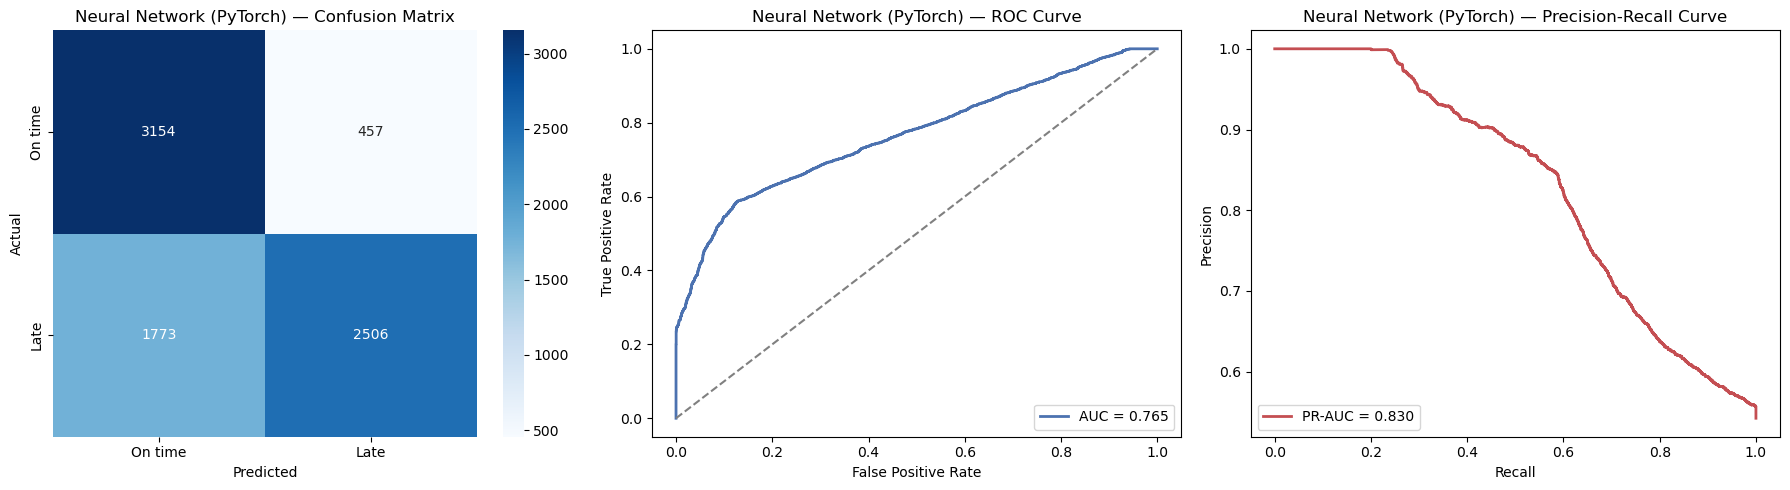

In [6]:
model.eval()
with torch.no_grad():
    val_logits = model(torch.tensor(X_val).to(device)).squeeze().cpu().numpy()
    y_score = 1 / (1 + np.exp(-val_logits))  # sigmoid
    y_pred = (y_score >= 0.5).astype(int)

nn_metrics = evaluate_and_plot(y_val, y_pred, y_score, 'Neural Network (PyTorch)', save_prefix='neural_network')


**What we found, and it's a genuine surprise worth reporting prominently, not downplaying:**

| Metric | Baseline | Logistic Regression | Random Forest | XGBoost | SVM (Linear) | Neural Network |
|---|---|---|---|---|---|---|
| Recall | 0.5349 | 0.5543 | **0.6172** | 0.6062 | 0.5618 | 0.5857 |
| Precision | 0.8391 | 0.8379 | 0.7924 | 0.8160 | 0.8394 | **0.8458** |
| F1 | 0.6533 | 0.6672 | 0.6939 | **0.6956** | 0.6731 | 0.6921 |
| ROC-AUC | 0.7270 | 0.7394 | 0.7580 | 0.7595 | 0.7392 | **0.7653** |
| PR-AUC | 0.7429 | 0.8105 | 0.8234 | 0.8250 | 0.8102 | **0.8301** |

**Contrary to what we said going in (that a neural network wasn't expected to beat XGBoost on tabular data at this scale), the neural network actually shows the best ROC-AUC, best PR-AUC, and best Precision of every model tested so far.** This is worth stating plainly and prominently rather than downplaying just because it wasn't the expected outcome, we said we'd report the result honestly either way, and the honest result here is that the deep learning approach genuinely earned its place in the comparison.

**One important nuance, though:** the neural network does **not** lead on Recall (0.5857), Random Forest still holds that lead (0.6172). Since Recall is our stated primary metric, this means the neural network isn't automatically the "winner" of the comparison, it's the strongest model on ranking quality and precision, but Random Forest is still ahead on the metric that matters most for the business problem. This is a genuinely useful, nuanced result for Stage 9's recommendation: different models are strongest on different axes, and the final choice should depend on Stage 8's threshold tuning (a high AUC model like the neural network might catch up on Recall once the classification threshold is optimized away from the default 0.5, since a high AUC means the model is ranking orders well even if the default cutoff undersells its Recall).



## 4. Save model and metrics

In [7]:
torch.save(model.state_dict(), '../../../models/neural_network.pt')
save_metrics(nn_metrics, '../../../data/processed/metrics_nn.json')


Saved metrics to ../../../data/processed/metrics_nn.json
